In [2]:
!pip install lightgbm optuna mlflow imbalanced-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887

In [3]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Metrics
from sklearn.metrics import roc_auc_score

# Model
from lightgbm import LGBMClassifier

# Hyperparameter tuning
import optuna

# ML tracking
import mlflow

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/datasets/train_transaction.csv')

In [6]:
train_df = train_df.sample(50000, random_state=42)

In [7]:
for col in train_df.select_dtypes(include='float64').columns:
    train_df[col] = train_df[col].astype('float32')

for col in train_df.select_dtypes(include='int64').columns:
    train_df[col] = train_df[col].astype('int32')

In [8]:
print(train_df.shape)

train_df.head()

(50000, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
470624,3457624,0,12153579,724.000000,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565820,3552820,0,15005886,108.500000,W,12544,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284083,3271083,0,6970178,47.950001,W,9400,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
239689,3226689,0,5673658,100.598999,C,15885,545.0,185.0,visa,138.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
281855,3268855,0,6886780,107.949997,W,15497,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
train_df['isFraud'].value_counts(normalize=True)

,proportion
isFraud,
0,0.96414
1,0.03586


In [10]:
missing = train_df.isnull().mean() * 100

missing.sort_values(ascending=False).head(20)

,0
dist2,93.730
D7,93.350
D13,89.530
D14,89.480
D12,88.990
D6,87.576
D9,87.276
D8,87.276
V153,86.064
V140,86.064


In [11]:
missing_cols = missing[missing > 80].index

train_df.drop(
    columns=missing_cols,
    inplace=True,
    errors='ignore'
)

In [12]:
X = train_df.drop(columns=['isFraud'])

y = train_df['isFraud']

In [13]:
categorical_cols = X.select_dtypes(include='object').columns

numerical_cols = X.select_dtypes(exclude='object').columns

In [14]:
num_imputer = SimpleImputer(strategy='median')

X[numerical_cols] = num_imputer.fit_transform(
    X[numerical_cols]
)

In [15]:
cat_imputer = SimpleImputer(strategy='most_frequent')

X[categorical_cols] = cat_imputer.fit_transform(
    X[categorical_cols]
)

In [16]:
for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1434, number of negative: 38566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080894 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24388
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 328
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035850 -> initscore=-3.291903
[LightGBM] [Info] Start training from score -3.291903


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [19]:
pred_prob = model.predict_proba(X_valid)[:,1]

auc = roc_auc_score(
    y_valid,
    pred_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9012222636667505


In [20]:
from sklearn.metrics import classification_report

pred_class = model.predict(X_valid)

print(classification_report(y_valid, pred_class))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9641
           1       0.92      0.37      0.52       359

    accuracy                           0.98     10000
   macro avg       0.95      0.68      0.76     10000
weighted avg       0.97      0.98      0.97     10000



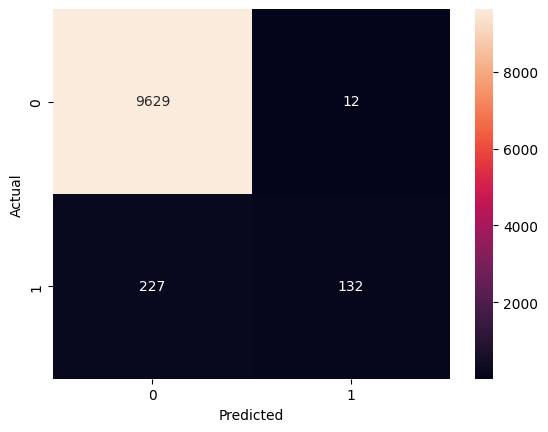

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

importance = importance.sort_values(
    by='importance',
    ascending=False
)

print(importance.head(20))

           feature  importance
0    TransactionID         379
2   TransactionAmt         331
4            card1         295
5            card2         247
10           addr1         181
27             C13         168
36             D15         161
15              C1         137
12           dist1         134
8            card5         124
30              D2         119
13   P_emaildomain         117
32              D4         103
34             D10          94
29              D1          94
31              D3          90
25             C11          72
28             C14          72
16              C2          69
33              D5          68


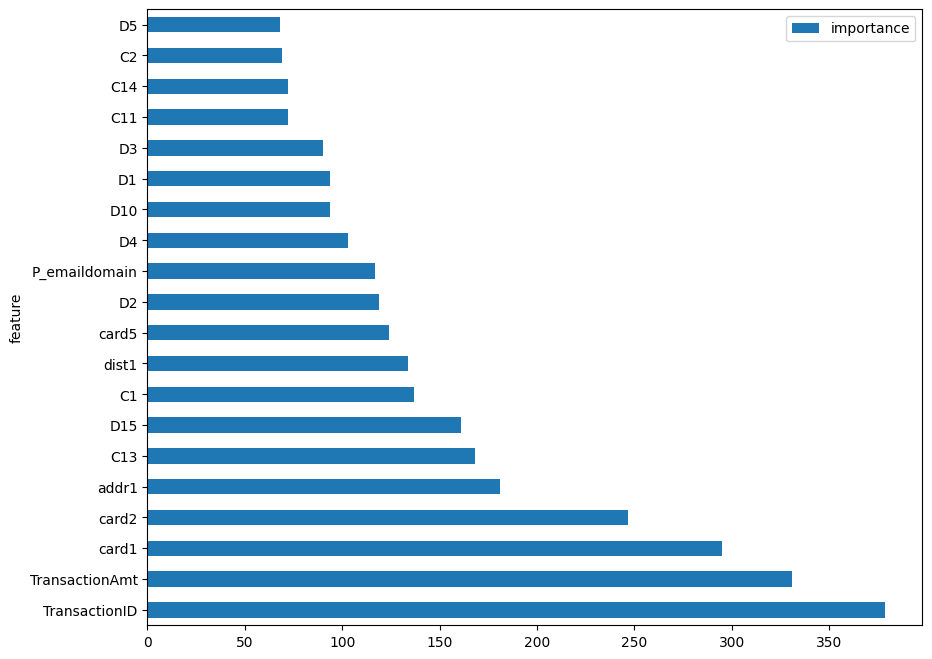

In [24]:
importance.head(20).plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10,8)
)

plt.show()

In [25]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

def objective(trial):

    params = {

        'n_estimators': trial.suggest_int(
            'n_estimators',
            100,
            500
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.1
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            10
        ),

        'num_leaves': trial.suggest_int(
            'num_leaves',
            20,
            100
        ),

        'random_state': 42
    }

    model = LGBMClassifier(**params)

    model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_valid)[:,1]

    auc = roc_auc_score(y_valid, pred_prob)

    return auc

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=20)

print(study.best_params)
print(study.best_value)

[I 2026-05-12 22:17:28,310] A new study created in memory with name: no-name-09ee1f3c-290a-4bbe-849b-9c58abcc6cb6


[LightGBM] [Info] Number of positive: 1434, number of negative: 38566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.085038 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24388
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 328
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035850 -> initscore=-3.291903
[LightGBM] [Info] Start training from score -3.291903
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-12 22:17:33,257] Trial 0 finished with value: 0.901783787266488 and parameters: {'n_estimators': 271, 'learning_rate': 0.04338842975477212, 'max_depth': 7, 'num_leaves': 27}. Best is trial 0 with value: 0.901783787266488.


[LightGBM] [Info] Number of positive: 1434, number of negative: 38566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082783 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24388
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 328
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035850 -> initscore=-3.291903
[LightGBM] [Info] Start training from score -3.291903
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-12 22:17:38,195] Trial 1 finished with value: 0.9011074164164827 and parameters: {'n_estimators': 380, 'learning_rate': 0.0954331576012909, 'max_depth': 5, 'num_leaves': 50}. Best is trial 0 with value: 0.901783787266488.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1434, number of negative: 38566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.083419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24388
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 328
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035850 -> initscore=-3.291903
[LightGBM] [Info] Start training from score -3.291903
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-12 22:19:20,942] Trial 18 finished with value: 0.8972713737955847 and parameters: {'n_estimators': 312, 'learning_rate': 0.07906844911202808, 'max_depth': 9, 'num_leaves': 49}. Best is trial 6 with value: 0.9060650616173557.


[LightGBM] [Info] Number of positive: 1434, number of negative: 38566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24388
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 328
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035850 -> initscore=-3.291903
[LightGBM] [Info] Start training from score -3.291903
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-12 22:19:28,440] Trial 19 finished with value: 0.8939582834337682 and parameters: {'n_estimators': 496, 'learning_rate': 0.05649744804348619, 'max_depth': 7, 'num_leaves': 79}. Best is trial 6 with value: 0.9060650616173557.


{'n_estimators': 421, 'learning_rate': 0.05826939960550341, 'max_depth': 6, 'num_leaves': 70}
0.9060650616173557


In [26]:
best_model = LGBMClassifier(
    **study.best_params
)

best_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1434, number of negative: 38566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.158673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24388
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 328
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035850 -> initscore=-3.291903
[LightGBM] [Info] Start training from score -3.291903
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(learning_rate=0.05826939960550341, max_depth=6, n_estimators=421,
               num_leaves=70)

In [27]:
best_pred = best_model.predict_proba(X_valid)[:,1]

best_auc = roc_auc_score(
    y_valid,
    best_pred
)

print(best_auc)

0.9060650616173557


In [28]:
import mlflow

with mlflow.start_run():

    mlflow.log_params(study.best_params)

    mlflow.log_metric(
        "roc_auc",
        best_auc
    )

2026/05/12 22:21:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/12 22:21:01 INFO mlflow.store.db.utils: Updating database tables
